# Task 2: End-to-End ML Pipeline with Scikit-learn Pipeline API

**Objective:** Build a reusable, production-ready ML pipeline to predict customer churn.

**Dataset:** Telco Customer Churn Dataset (7,043 customers, 21 columns)

**What this notebook covers:**
- Data cleaning & exploration
- Preprocessing (scaling + encoding) using `Pipeline` / `ColumnTransformer`
- Training Logistic Regression and Random Forest inside a single pipeline
- Hyperparameter tuning with `GridSearchCV`
- Model evaluation and comparison
- Exporting the final pipeline with `joblib` for reuse in production


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load the Dataset

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## 2. Data Cleaning

- `TotalCharges` is loaded as text because a few new customers (tenure = 0) have blank values instead of numbers.
- `customerID` is just an identifier, not a predictive feature, so it is dropped.
- The target column `Churn` (Yes/No) is converted to 1/0.


In [6]:
# TotalCharges has blank strings for a few rows -> convert to numeric, coercing errors to NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Missing values after conversion:\n", df.isnull().sum()[df.isnull().sum() > 0])

# Fill the few missing TotalCharges with 0 (these are customers with tenure = 0, i.e. brand new)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop identifier column
df.drop(columns=["customerID"], inplace=True)

# Encode target: Yes -> 1, No -> 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

df.head()


Missing values after conversion:
 TotalCharges    11
dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 3. Quick Exploratory Data Analysis

Churn distribution:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


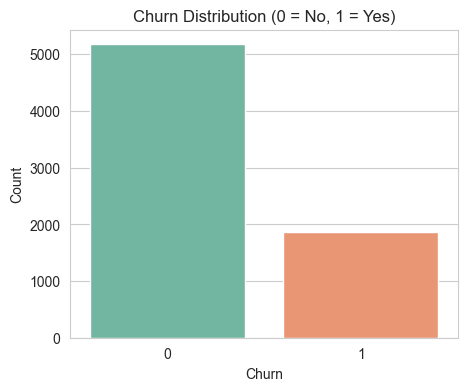

In [7]:
print("Churn distribution:")
print(df["Churn"].value_counts(normalize=True).rename("proportion"))

plt.figure(figsize=(5, 4))
sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Churn Distribution (0 = No, 1 = Yes)")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


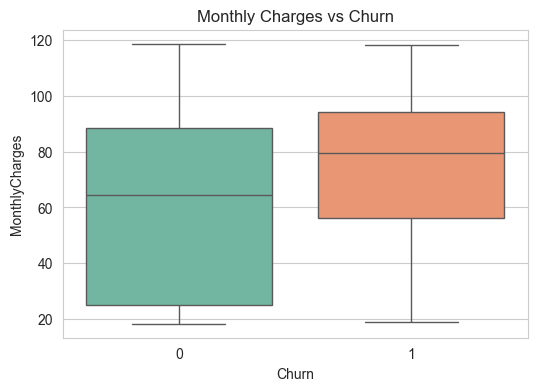

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, palette="Set2")
plt.title("Monthly Charges vs Churn")
plt.show()


## 4. Train/Test Split

We separate features (`X`) from the target (`y`), then split into training and test sets
(80/20) using stratification so both sets keep the same churn ratio.


In [9]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (5634, 19)
Test shape: (1409, 19)


## 5. Preprocessing Pipeline

We identify numeric and categorical columns, then build a `ColumnTransformer` that:
- Scales numeric features with `StandardScaler`
- One-hot encodes categorical features with `OneHotEncoder`

This preprocessor will be the first step of our full modeling `Pipeline`, so scaling and
encoding are learned only on the training data (no data leakage) and are automatically
applied to any new data at prediction time.


In [10]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)


Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 6. Build Full Pipelines (Preprocessing + Model)

Each pipeline bundles preprocessing and the classifier together, so we can fit, tune,
and export it as a single object.


In [11]:
log_reg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])


## 7. Hyperparameter Tuning with GridSearchCV

We tune each pipeline with 5-fold cross-validation, optimizing for F1-score
(a good balance of precision/recall for the moderately imbalanced churn target).


In [12]:
log_reg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

log_reg_grid = GridSearchCV(
    log_reg_pipeline, log_reg_param_grid,
    cv=5, scoring="f1", n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression params:", log_reg_grid.best_params_)
print("Best CV F1-score:", round(log_reg_grid.best_score_, 4))


Best Logistic Regression params: {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Best CV F1-score: 0.5989


In [13]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2]
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring="f1", n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest params:", rf_grid.best_params_)
print("Best CV F1-score:", round(rf_grid.best_score_, 4))


Best Random Forest params: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1-score: 0.5773


## 8. Model Evaluation on Test Set

Now we evaluate both tuned pipelines on the held-out test set.


In [14]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    return results, y_pred

log_reg_results, log_reg_preds = evaluate_model("Logistic Regression", log_reg_grid.best_estimator_, X_test, y_test)
rf_results, rf_preds = evaluate_model("Random Forest", rf_grid.best_estimator_, X_test, y_test)

results_df = pd.DataFrame([log_reg_results, rf_results]).set_index("Model")
results_df


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Logistic Regression,0.804826,0.655172,0.558824,0.603175,0.841238
Random Forest,0.807665,0.671096,0.540107,0.598519,0.841121


In [15]:
print("Logistic Regression - Classification Report")
print(classification_report(y_test, log_reg_preds))

print("\nRandom Forest - Classification Report")
print(classification_report(y_test, rf_preds))


Logistic Regression - Classification Report
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


Random Forest - Classification Report
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



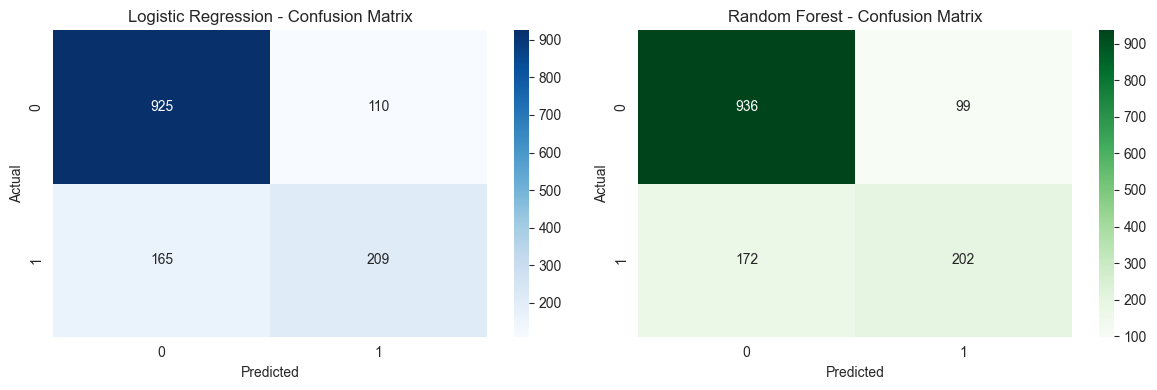

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, log_reg_preds), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Random Forest - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


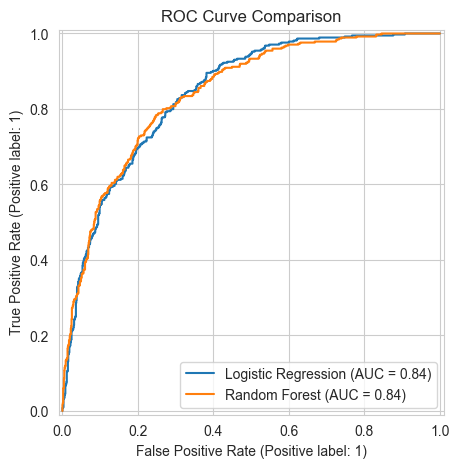

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(log_reg_grid.best_estimator_, X_test, y_test, ax=ax, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf_grid.best_estimator_, X_test, y_test, ax=ax, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()


## 9. Select the Best Pipeline and Export with joblib

We pick the pipeline with the higher F1-score on the test set and export the **entire**
pipeline (preprocessing + tuned model) as a single `.joblib` file. Because preprocessing
lives inside the pipeline, the saved file can take in raw, unprocessed customer data and
return predictions directly &mdash; no separate scaler/encoder files needed.


In [18]:
best_model_name = results_df["F1-score"].idxmax()
best_pipeline = log_reg_grid.best_estimator_ if best_model_name == "Logistic Regression" else rf_grid.best_estimator_

print(f"Best performing model: {best_model_name}")
print(results_df.loc[best_model_name])

joblib.dump(best_pipeline, "churn_prediction_pipeline.joblib")
print("\nPipeline exported to churn_prediction_pipeline.joblib")


Best performing model: Logistic Regression
Accuracy     0.804826
Precision    0.655172
Recall       0.558824
F1-score     0.603175
ROC-AUC      0.841238
Name: Logistic Regression, dtype: float64

Pipeline exported to churn_prediction_pipeline.joblib


## 10. Reload the Pipeline and Predict on New Data

This simulates production usage: load the saved pipeline and predict on a few
raw, unseen customer records.


In [19]:
loaded_pipeline = joblib.load("churn_prediction_pipeline.joblib")

sample = X_test.head(5)
predictions = loaded_pipeline.predict(sample)
probabilities = loaded_pipeline.predict_proba(sample)[:, 1]

result = sample.copy()
result["Predicted_Churn"] = predictions
result["Churn_Probability"] = probabilities.round(3)
result[["Predicted_Churn", "Churn_Probability"]]


,Predicted_Churn,Churn_Probability
437,0,0.048
2280,1,0.682
2235,0,0.050
4460,0,0.422
3761,0,0.023


## 11. Summary

- Built a single, reusable `Pipeline` that combines preprocessing (`StandardScaler` +
  `OneHotEncoder` via `ColumnTransformer`) with the classifier, avoiding data leakage.
- Trained and tuned **Logistic Regression** and **Random Forest** with `GridSearchCV`
  (5-fold CV, optimized for F1-score).
- Compared both models on accuracy, precision, recall, F1-score, and ROC-AUC.
- Exported the best pipeline with `joblib` as `churn_prediction_pipeline.joblib`,
  ready to be loaded and used for predictions on new, unprocessed customer data —
  a production-ready artifact.

**Skills demonstrated:** ML pipeline construction, hyperparameter tuning with
`GridSearchCV`, model export & reusability, production-readiness practices.
